In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, log_loss, roc_auc_score,
    roc_curve, auc, matthews_corrcoef
)
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
# ==============================
# 2. LOAD DATA
# ==============================
train_df = pd.read_excel("/content/drive/MyDrive/CBC Data/CBC indices data set/5778-Non-SMOTE-NC.xlsx")

test_df = pd.read_excel("/content/drive/MyDrive/CBC Data/CBC indices data set/625-External data.xlsx")

In [34]:
# ==============================
# 3. CLEAN
# ==============================
def clean(df):
    df.columns = df.columns.str.strip().str.upper()
    return df

train_df = clean(train_df)
test_df  = clean(test_df)

drop_cols = ['NO','SEX','AGE']
train_df = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
test_df  = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])

In [35]:
# ==============================
# 4. FEATURE ENGINEERING
# ==============================
def fe(df):
    df = df.copy()
    eps = 1e-6
    df['MENTZER'] = df['MCV']/(df['RBC']+eps)
    df['RDW_MCV'] = df['RDW']/(df['MCV']+eps)
    df['MCV_RBC'] = df['MCV']/(df['RBC']+eps)
    df['MCH_MCV'] = df['MCH']/(df['MCV']+eps)
    return df

train_df = fe(train_df)
test_df  = fe(test_df)

In [36]:
# ==============================
# 5. FEATURES
# ==============================
features = [
    'RBC','MCV','MCH','RDW','HGB','HCT',
    'MENTZER','RDW_MCV','MCV_RBC','MCH_MCV'
]

TARGET = 'LABEL'

X = train_df[features]
y = train_df[TARGET]

X_test = test_df[features]
y_test = test_df[TARGET]

In [37]:
# ==============================
# 6. SPLIT
# ==============================
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [38]:
# ==============================
# 🔥 7. SMOTE (ONLY TRAIN)
# ==============================
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [39]:
# ==============================
# 🔥 8. MODEL (ANTI-OVERFITTING RF)
# ==============================
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,        # ↓ fewer trees (less memorization)
    max_depth=6,             # ↓ shallow trees
    min_samples_split=10,    # ↑ harder to split
    min_samples_leaf=5,      # ↑ smoother leaves
    max_features=0.6,        # ↓ randomness (important)
    bootstrap=True,
    oob_score=True,          # extra generalization check
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_sm, y_train_sm)

RandomForestClassifier(max_depth=6, max_features=0.6, min_samples_leaf=5,
                       min_samples_split=10, n_estimators=300, n_jobs=-1,
                       oob_score=True, random_state=42)

In [40]:
# ==============================
# 9. PREDICTION
# ==============================
y_train_pred = model.predict(X_train)
y_val_pred   = model.predict(X_val)
y_test_pred  = model.predict(X_test)

y_val_prob   = model.predict_proba(X_val)
y_test_prob  = model.predict_proba(X_test)

In [41]:
# ==============================
# 🔥 9.5 OVERALL ACCURACY
# ==============================
print("\n===== OVERALL ACCURACY =====")
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))


===== OVERALL ACCURACY =====
Train Accuracy: 0.7907832107312852
Validation Accuracy: 0.7941176470588235
Test Accuracy: 0.7392


In [42]:
# ==============================
# 🔥 10. METRICS
# ==============================
def specificity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    spec = []
    for i in range(len(cm)):
        tn = np.sum(cm) - (np.sum(cm[i,:]) + np.sum(cm[:,i]) - cm[i,i])
        fp = np.sum(cm[:,i]) - cm[i,i]
        spec.append(tn / (tn + fp + 1e-6))
    return np.mean(spec)


def evaluate(y_true, y_pred, y_prob, name):
    print(f"\n===== {name} =====")

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall:", recall_score(y_true, y_pred, average='weighted'))
    print("F1:", f1_score(y_true, y_pred, average='weighted'))
    print("MCC:", matthews_corrcoef(y_true, y_pred))
    print("Specificity:", specificity_score(y_true, y_pred))
    print("LogLoss:", log_loss(y_true, y_prob))

    print("AUC Macro:",
          roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro'))
    print("AUC Weighted:",
          roc_auc_score(y_true, y_prob, multi_class='ovr', average='weighted'))

In [43]:
# ==============================
# 11. EVALUATION
# ==============================
evaluate(y_val, y_val_pred, y_val_prob, "VALIDATION")
evaluate(y_test, y_test_pred, y_test_prob, "TEST")


===== VALIDATION =====
Accuracy: 0.7941176470588235
Precision: 0.7998399413681075
Recall: 0.7941176470588235
F1: 0.7963114294297206
MCC: 0.6668354415166505
Specificity: 0.9296950111229562
LogLoss: 0.5698562120046898
AUC Macro: 0.9146388516701965
AUC Weighted: 0.9368809638424381

===== TEST =====
Accuracy: 0.7392
Precision: 0.7651393416300615
Recall: 0.7392
F1: 0.7471347732235248
MCC: 0.6340461929431738
Specificity: 0.9159082138992144
LogLoss: 0.7189998888347481
AUC Macro: 0.9049913960928054
AUC Weighted: 0.9206861441661441


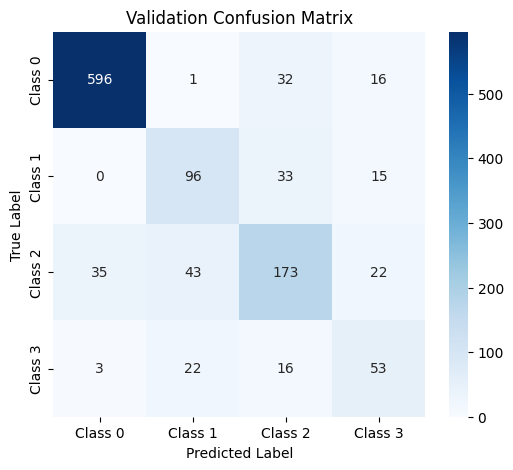

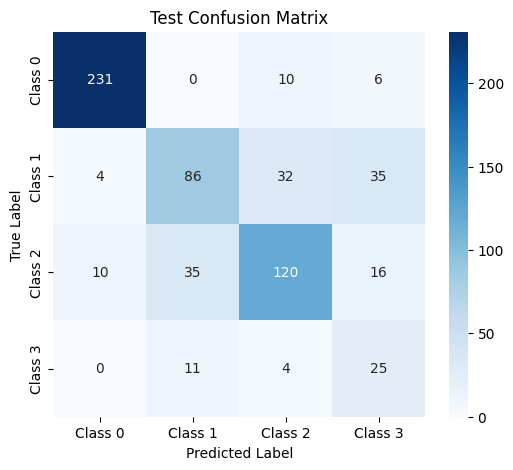

In [44]:
# ==============================
# 🔥 12. CONFUSION MATRIX PLOT
# ==============================
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    labels = ["Class 0", "Class 1", "Class 2", "Class 3"]

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()


plot_confusion_matrix(y_val, y_val_pred, "Validation Confusion Matrix")
plot_confusion_matrix(y_test, y_test_pred, "Test Confusion Matrix")

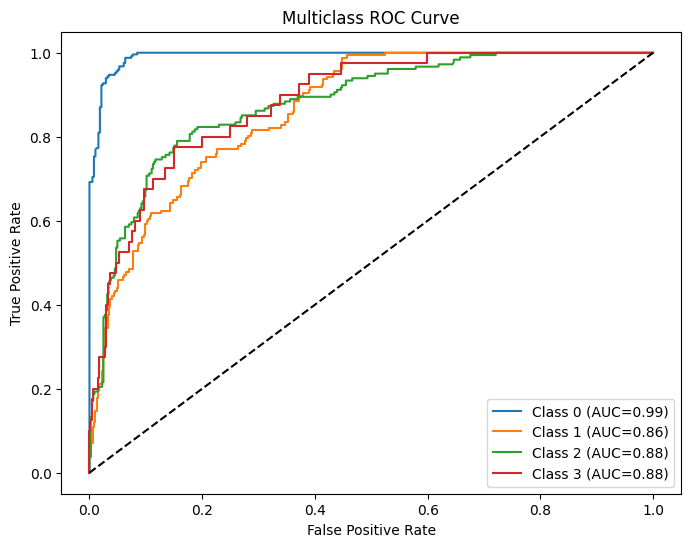

In [45]:
# ==============================
# 🔥 13. MULTICLASS ROC CURVE
# ==============================
n_classes = 4
y_test_bin = label_binarize(y_test, classes=[0,1,2,3])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_test_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC={roc_auc[i]:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend()
plt.show()